In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('A_공유자전거_대여운영_dirty.csv')
df.head()

,rental_id,station_zone,member_type,weather,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return
0,R0001,공원,일일권,비,31.5,77.0,5.6,4.11,NaN,28.0,0
1,R0002,도심,월회원,흐림,23.3,74.6,4.6,1.35,11.0,33.0,0
2,R0003,공원,일일권,맑음,22.5,56.3,1.0,1.49,11.6,31.0,0
3,R0004,공원,연회원,흐림,28.6,77.3,2.0,6.73,27.5,21.0,0
4,R0005,공원,월회원,맑음,13.0,46.3,0.8,3.09,17.5,42.0,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 652 entries, 0 to 651
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rental_id          652 non-null    str    
 1   station_zone       652 non-null    str    
 2   member_type        629 non-null    str    
 3   weather            635 non-null    str    
 4   temperature_c      652 non-null    float64
 5   humidity_pct       627 non-null    float64
 6   wind_speed_mps     652 non-null    float64
 7   distance_km        652 non-null    float64
 8   ride_duration_min  631 non-null    float64
 9   bike_age_months    638 non-null    float64
 10  late_return        652 non-null    int64  
dtypes: float64(6), int64(1), str(4)
memory usage: 56.2 KB


In [3]:
df.shape

(652, 11)

In [4]:
df.describe(include='all')

,rental_id,station_zone,member_type,weather,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return
count,652,652,629,635,652.000000,627.000000,652.000000,652.000000,631.000000,638.000000,652.000000
unique,644,4,3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,R0019,주거,월회원,맑음,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,192,245,375,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,22.854755,62.670175,3.218558,4.318466,22.682092,22.354232,0.050613
std,NaN,NaN,NaN,NaN,6.487134,15.228703,1.392390,5.384499,24.133076,10.928047,0.219375
min,NaN,NaN,NaN,NaN,-19.100000,28.000000,0.200000,0.680000,4.000000,1.000000,0.000000
25%,NaN,NaN,NaN,NaN,19.000000,51.750000,2.200000,2.180000,13.500000,14.000000,0.000000
50%,NaN,NaN,NaN,NaN,22.600000,61.500000,3.200000,3.280000,18.600000,22.000000,0.000000
75%,NaN,NaN,NaN,NaN,27.225000,72.100000,4.200000,4.910000,24.900000,29.000000,0.000000


In [5]:
df.isnull().sum()

rental_id             0
station_zone          0
member_type          23
weather              17
temperature_c         0
humidity_pct         25
wind_speed_mps        0
distance_km           0
ride_duration_min    21
bike_age_months      14
late_return           0
dtype: int64

In [6]:
missing_df = pd.DataFrame({
    '결측치 개수': df.isnull().sum(),
    '결측 비율': df.isnull().mean()
})

display(missing_df)

,결측치 개수,결측 비율
rental_id,0,0.000000
station_zone,0,0.000000
member_type,23,0.035276
weather,17,0.026074
temperature_c,0,0.000000
humidity_pct,25,0.038344
wind_speed_mps,0,0.000000
distance_km,0,0.000000
ride_duration_min,21,0.032209
bike_age_months,14,0.021472


In [7]:
total_duplicates = df.duplicated().sum()
total_duplicates

np.int64(6)

In [8]:
rental_duplicates = df.duplicated(subset=['rental_id']).sum()
rental_duplicates

np.int64(8)

#### 3번과 4번 결과가 다른 이유:
- 완전 중복(6개)은 모든 값이 똑같은 데이터고, rental_id 중복(8개)은 대여 ID는 같은데 기온이나 습도 같은 수치만 살짝 다르게 들어간 데이터가 2개 더 있어서 다름.

#### rental_id
- rental_id는 대여건을 구분하려는 단순 대여 식별자일 뿐이라, 반납 지연을 분석하거나 예측하는 피처는 아니다.

In [9]:
print("중복 행 개수 :", df.duplicated().sum())
print("제거 전 행 개수 :", len(df))

df = df.drop_duplicates()

print("제거 후 행 개수 :", len(df))

중복 행 개수 : 6
제거 전 행 개수 : 652
제거 후 행 개수 : 646


In [10]:
print("rental_id 중복 개수 :", df["rental_id"].duplicated().sum())

df[df["rental_id"].duplicated(keep=False)]

rental_id 중복 개수 : 2


,rental_id,station_zone,member_type,weather,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return
63,R0064,대학가,일일권,흐림,29.0,72.4,1.6,1.44,205.7,37.0,0
136,R0137,주거,일일권,비,19.3,70.7,3.7,4.13,27.0,16.0,0
650,R0064,대학가,일일권,흐림,29.4,76.3,1.6,1.44,205.7,37.0,0
651,R0137,주거,일일권,비,19.8,73.8,3.7,4.13,27.0,16.0,0


#### rental_id 중복 처리 기준
- 동일 rental_id가 두 번 기록된 경우, 기온·습도 등 수치가 미세하게 다름 → 값이 재수집/보정되어 파일 뒤쪽에 다시 기록된 것으로 판단
- 따라서 최신 값 우선(keep='last') 기준으로 뒤에 있는 행을 남김

In [11]:
df = df.drop_duplicates(subset="rental_id", keep="last")

print(df["rental_id"].duplicated().sum())

0


In [12]:
num_cols = df.select_dtypes(include='number').columns
num_cols_na = num_cols[df[num_cols].isnull().any()]

cat_cols = df.select_dtypes(exclude='number').columns
cat_cols_na = cat_cols[df[cat_cols].isnull().any()]

print(df[num_cols_na].isnull().sum())
print('-----------------------------')
print(df[cat_cols_na].isnull().sum())

humidity_pct         25
ride_duration_min    21
bike_age_months      14
dtype: int64
-----------------------------
member_type    22
weather        17
dtype: int64


In [13]:
for c in cat_cols_na:
    df[c] = df[c].fillna(df[c].mode()[0])

In [14]:
for c in num_cols_na:
    df[c] = df[c].fillna(df[c].median())

df.isnull().sum()

rental_id            0
station_zone         0
member_type          0
weather              0
temperature_c        0
humidity_pct         0
wind_speed_mps       0
distance_km          0
ride_duration_min    0
bike_age_months      0
late_return          0
dtype: int64

### 결측치 처리 방법 선택 이유

1. 범주형 컬럼 (member_type, weather) → 최빈값(Mode) 채움
   - 이유: 수치 연산이 불가능하므로 가장 자주 등장한 값으로 채워 분포 변형을 줄임.

2. 수치형 컬럼 (humidity_pct, ride_duration_min, bike_age_months) → 중앙값(Median) 대체
   - 이유: 주행시간 등은 극단적 이상치의 영향을 크게 받아서 평균보다 이상치에 훨씬 강한 중앙값이 안전하기 때문.

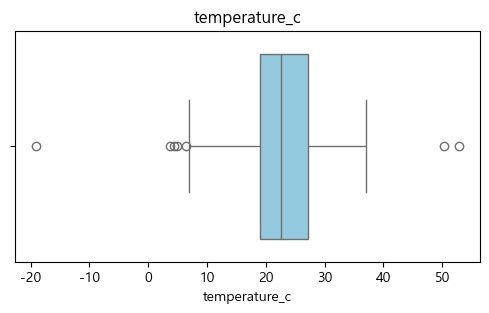

In [15]:
plt.figure(figsize=(6, 3))
sns.boxplot(x=df['temperature_c'], color='skyblue')
plt.title('temperature_c')
plt.show()

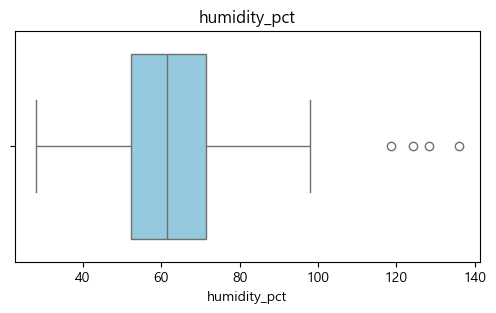

In [16]:
plt.figure(figsize=(6, 3))
sns.boxplot(x=df['humidity_pct'], color='skyblue')
plt.title('humidity_pct')
plt.show()

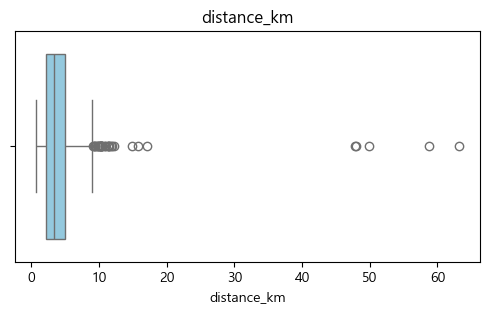

In [17]:
plt.figure(figsize=(6, 3))
sns.boxplot(x=df['distance_km'], color='skyblue')
plt.title('distance_km')
plt.show()

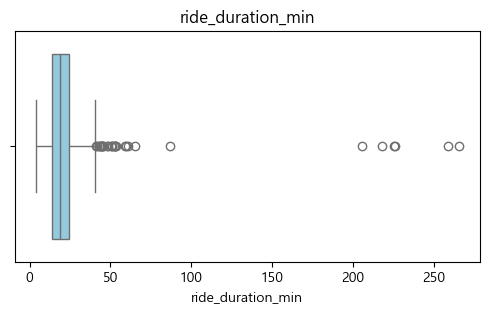

In [18]:
plt.figure(figsize=(6, 3))
sns.boxplot(x=df['ride_duration_min'], color='skyblue')
plt.title('ride_duration_min')
plt.show()

In [19]:
q1 = df['temperature_c'].quantile(.25)

q3 = df['temperature_c'].quantile(.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

n_outlier = ((df['temperature_c'] < lower) | (df['temperature_c'] > upper)).sum()
n_outlier

np.int64(7)

In [20]:
q1 = df['humidity_pct'].quantile(.25)

q3 = df['humidity_pct'].quantile(.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

n_outlier = ((df['humidity_pct'] < lower) | (df['humidity_pct'] > upper)).sum()
n_outlier

np.int64(4)

In [21]:
q1 = df['distance_km'].quantile(.25)

q3 = df['distance_km'].quantile(.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

n_outlier = ((df['distance_km'] < lower) | (df['distance_km'] > upper)).sum()
n_outlier

np.int64(33)

In [22]:
q1 = df['ride_duration_min'].quantile(.25)

q3 = df['ride_duration_min'].quantile(.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

n_outlier = ((df['ride_duration_min'] < lower) | (df['ride_duration_min'] > upper)).sum()
n_outlier

np.int64(31)

1. 통계적으로 드물지만 실제로 가능할 수 있는 값
    - temperature_c, distance_km, ride_duration_min
2. 습도 100% 초과처럼 도메인 규칙을 위반한 값
    - humidity_pct

#### temperature_c -> 원본 값 유지 + 이상치 여부 플래그 생성
- 값을 변형하지 않고 원본을 그대로 유지해야 기후 특성이 왜곡 되지 않음.

#### humidity_pct -> 현실 범위 경계값으로 보정
- 습도는 물리적으로 100%를 넘을 수 없으므로 도메인 한계선인 100%로 보정.

#### distance_km -> IQR 경계값으로 capping
- 장거리 이용자의 데이터 손실을 막으면서 극단값의 통계 왜곡을 줄이기 위해 상한선으로 capping

#### ride_duration_min -> IQR 경계값으로 capping
- 장시간 대여로 인한 극단값이 모델에 미치는 영향을 완화하기 위해 상한선으로 capping

In [23]:
df_orig = df.copy()

In [24]:
q1 = df['temperature_c'].quantile(.25)
q3 = df['temperature_c'].quantile(.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

df['temperature_c_outlier'] = ((df['temperature_c'] < lower) | (df['temperature_c'] > upper)).astype(int)

print(df['temperature_c_outlier'].value_counts())

temperature_c_outlier
0    637
1      7
Name: count, dtype: int64


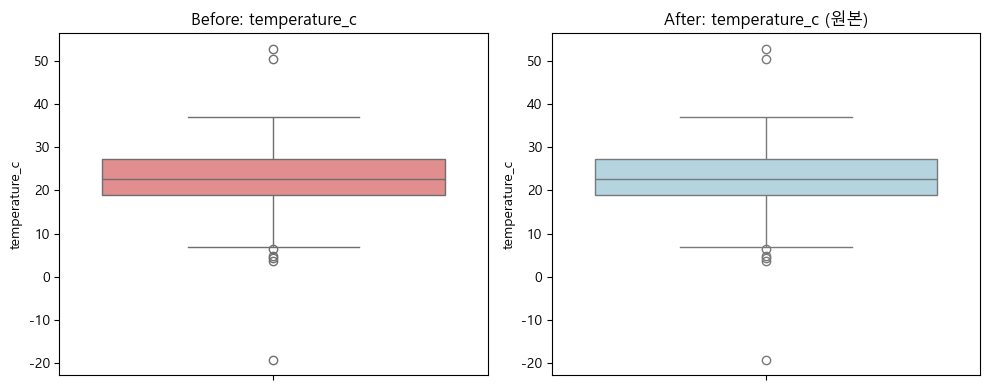

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df_orig['temperature_c'], ax=axes[0], color='lightcoral')
axes[0].set_title('Before: temperature_c')

sns.boxplot(y=df['temperature_c'], ax=axes[1], color='lightblue')
axes[1].set_title('After: temperature_c (원본)')

plt.tight_layout()
plt.show()

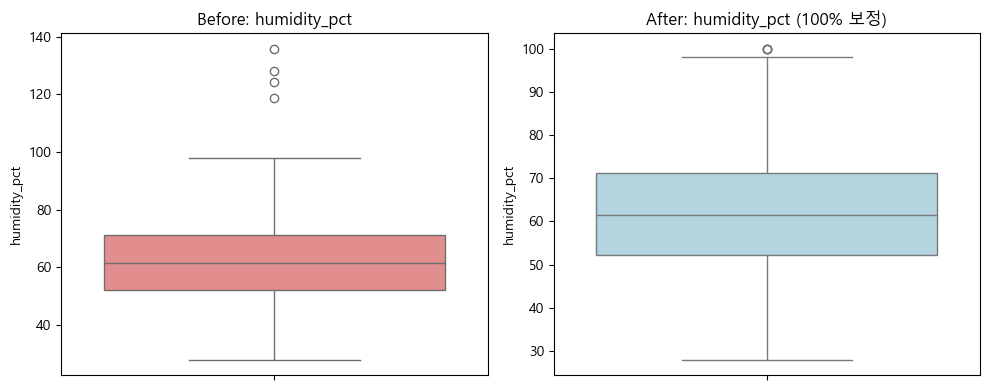

In [26]:
df['humidity_pct'] = df['humidity_pct'].clip(lower=0, upper=100)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df_orig['humidity_pct'], ax=axes[0], color='lightcoral')
axes[0].set_title('Before: humidity_pct')

sns.boxplot(y=df['humidity_pct'], ax=axes[1], color='lightblue')
axes[1].set_title('After: humidity_pct (100% 보정)')

plt.tight_layout()
plt.show()

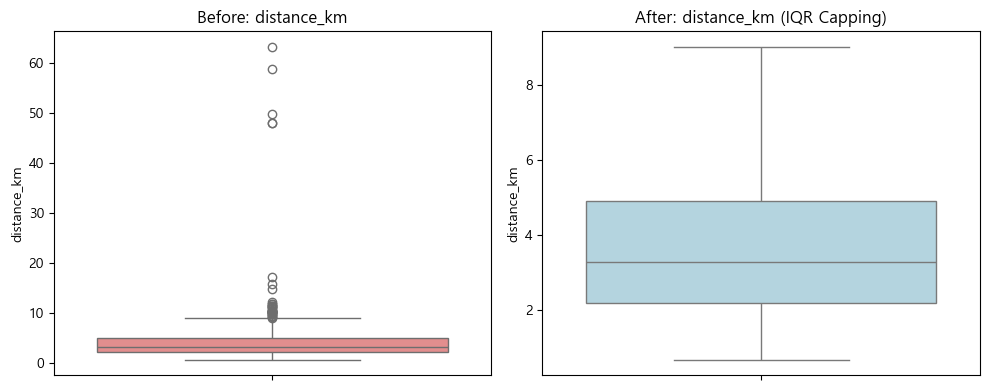

In [27]:
q1 = df['distance_km'].quantile(0.25)
q3 = df['distance_km'].quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr
lower = q1 - 1.5 * iqr

df['distance_km'] = df['distance_km'].clip(lower=lower, upper=upper)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df_orig['distance_km'], ax=axes[0], color='lightcoral')
axes[0].set_title('Before: distance_km')

sns.boxplot(y=df['distance_km'], ax=axes[1], color='lightblue')
axes[1].set_title('After: distance_km (IQR Capping)')

plt.tight_layout()
plt.show()

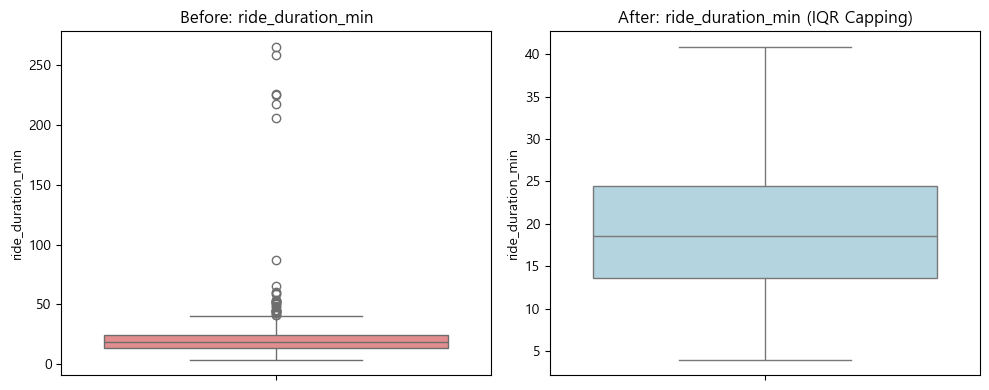

In [28]:
q1 = df['ride_duration_min'].quantile(0.25)
q3 = df['ride_duration_min'].quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr
lower = q1 - 1.5 * iqr

df['ride_duration_min'] = df['ride_duration_min'].clip(lower=lower, upper=upper)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df_orig['ride_duration_min'], ax=axes[0], color='lightcoral')
axes[0].set_title('Before: ride_duration_min')

sns.boxplot(y=df['ride_duration_min'], ax=axes[1], color='lightblue')
axes[1].set_title('After: ride_duration_min (IQR Capping)')

plt.tight_layout()
plt.show()

In [29]:
df['bad_weather'] = df['weather'].apply(lambda x: 1 if x in ['비', 'Rain'] else 0)

df['avg_speed_kmh'] = df['distance_km'] / (df['ride_duration_min'] / 60)

df[['bad_weather', 'avg_speed_kmh']].head()

,bad_weather,avg_speed_kmh
0,1,13.258065
1,0,7.363636
2,0,7.706897
3,0,14.683636
4,0,10.594286


In [30]:
df['avg_speed_kmh'] = df['avg_speed_kmh'].replace([np.inf, -np.inf], np.nan).fillna(0)

df['avg_speed_kmh'] = df['avg_speed_kmh'].clip(lower=0, upper=80)

invalid_cnt = ((df['avg_speed_kmh'] < 0) | (df['avg_speed_kmh'] > 80)).sum()
print(f"비정상 속도 데이터 개수: {invalid_cnt}개")
print(df['avg_speed_kmh'].describe())

비정상 속도 데이터 개수: 0개
count    644.000000
mean      11.365351
std        4.072938
min        2.115055
25%        9.272113
50%       11.116155
75%       13.014932
max       51.457143
Name: avg_speed_kmh, dtype: float64


In [31]:
df_eda = df.copy()

In [32]:
shape_before_encoding = df.shape

cat_cols_for_ohe = ['station_zone', 'member_type', 'weather']

df = pd.get_dummies(df, columns=cat_cols_for_ohe)

print("인코딩 후 shape:", df.shape)
df.head()

인코딩 후 shape: (644, 21)


,rental_id,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return,temperature_c_outlier,bad_weather,...,station_zone_공원,station_zone_대학가,station_zone_도심,station_zone_주거,member_type_연회원,member_type_월회원,member_type_일일권,weather_맑음,weather_비,weather_흐림
0,R0001,31.5,77.0,5.6,4.11,18.6,28.0,0,0,1,...,True,False,False,False,False,False,True,False,True,False
1,R0002,23.3,74.6,4.6,1.35,11.0,33.0,0,0,0,...,False,False,True,False,False,True,False,False,False,True
2,R0003,22.5,56.3,1.0,1.49,11.6,31.0,0,0,0,...,True,False,False,False,False,False,True,True,False,False
3,R0004,28.6,77.3,2.0,6.73,27.5,21.0,0,0,0,...,True,False,False,False,True,False,False,False,False,True
4,R0005,13.0,46.3,0.8,3.09,17.5,42.0,0,0,0,...,True,False,False,False,False,True,False,True,False,False


In [33]:
exclude_cols = ['rental_id', 'late_return']

dummy_cols = [c for c in df.columns if c.startswith(('station_zone_', 'member_type_', 'weather_'))]
binary_flag_cols = ['bad_weather', 'temperature_c_outlier']

scale_target_cols = [
    c for c in df.select_dtypes(include='number').columns
    if c not in exclude_cols + dummy_cols + binary_flag_cols
]

scaler = StandardScaler()
df[scale_target_cols] = scaler.fit_transform(df[scale_target_cols])

df[scale_target_cols].describe()

,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,avg_speed_kmh
count,6.440000e+02,6.440000e+02,6.440000e+02,6.440000e+02,6.440000e+02,6.440000e+02,6.440000e+02
mean,-3.309982e-17,-2.592819e-16,-3.116899e-16,1.958406e-16,-1.820490e-16,6.068300e-17,3.337565e-16
std,1.000777e+00,1.000777e+00,1.000777e+00,1.000777e+00,1.000777e+00,1.000777e+00,1.000777e+00
min,-6.459488e+00,-2.400986e+00,-2.177305e+00,-1.506748e+00,-1.859788e+00,-1.975888e+00,-2.272926e+00
25%,-5.910442e-01,-7.084015e-01,-7.380602e-01,-7.850706e-01,-7.505840e-01,-7.729111e-01,-5.143375e-01
50%,-3.654563e-02,-6.758785e-02,-1.843754e-02,-2.558406e-01,-1.728736e-01,-3.261774e-02,-6.123094e-02
75%,6.719804e-01,6.150180e-01,7.011851e-01,5.283821e-01,5.088247e-01,6.151389e-01,4.053249e-01
max,4.615082e+00,2.614078e+00,3.651638e+00,2.498561e+00,2.397938e+00,3.483776e+00,9.851108e+00


In [34]:
shape_after_encoding = df.shape

print("인코딩 전 shape :", shape_before_encoding)
print("인코딩 후 shape :", shape_after_encoding)
print("증가한 컬럼 수 :", shape_after_encoding[1] - shape_before_encoding[1])

df.to_csv('A_공유자전거_cleaned.csv', index=False)
print("저장 완료: A_공유자전거_cleaned.csv")

인코딩 전 shape : (644, 14)
인코딩 후 shape : (644, 21)
증가한 컬럼 수 : 7
저장 완료: A_공유자전거_cleaned.csv


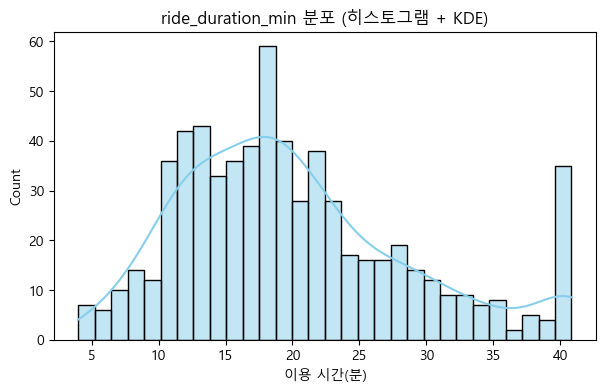

In [35]:
plt.figure(figsize=(7, 4))
sns.histplot(df_eda['ride_duration_min'], kde=True, color='skyblue', bins=30)
plt.title('ride_duration_min 분포 (히스토그램 + KDE)')
plt.xlabel('이용 시간(분)')
plt.show()

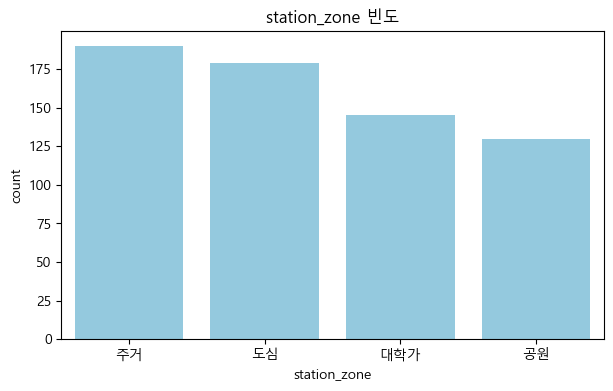

In [36]:
plt.figure(figsize=(7, 4))
sns.countplot(x='station_zone', data=df_eda, order=df_eda['station_zone'].value_counts().index, color='skyblue')
plt.title('station_zone 빈도')
plt.show()

In [37]:
late_return_counts = df_eda['late_return'].value_counts()
late_return_ratio = df_eda['late_return'].value_counts(normalize=True)

late_summary = pd.DataFrame({
    '건수': late_return_counts,
    '비율': late_return_ratio
})

print(late_summary)

              건수        비율
late_return               
0            613  0.951863
1             31  0.048137


#### 지연 건수가 적을 때 해석 시 주의점
- late_return=1인 표본 수 자체가 적으면, 그래프(boxplot 등)에 찍히는 값 하나하나가 전체 평균/분포를 크게 흔들 수 있음 → 소수 극단값에 결론이 좌우될 위험
- 지연 그룹의 평균값이 통계적으로 유의미한 차이인지, 단순히 표본이 작아서 우연히 튄 값인지 구분이 필요함
- 지연 비율이 낮다는 것 자체가 "지연이 드문 현상"이라는 의미이므로, 지연 그룹과 정상 그룹을 1:1 비교하듯 해석하면 과대 해석이 될 수 있음

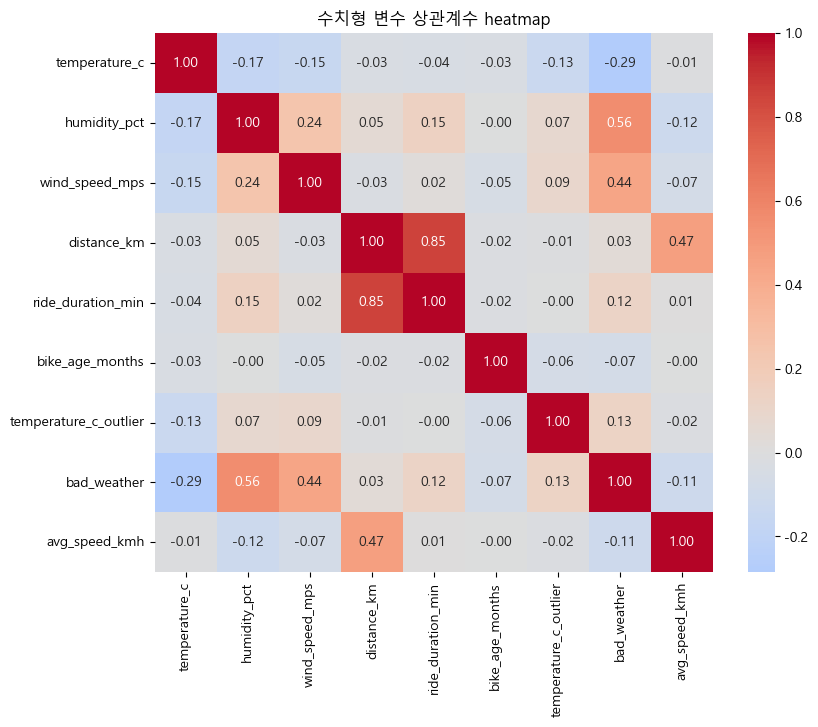

In [38]:
num_cols_for_corr = df_eda.select_dtypes(include='number').drop(columns=['late_return'], errors='ignore').columns

corr_matrix = df_eda[num_cols_for_corr].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('수치형 변수 상관계수 heatmap')
plt.show()

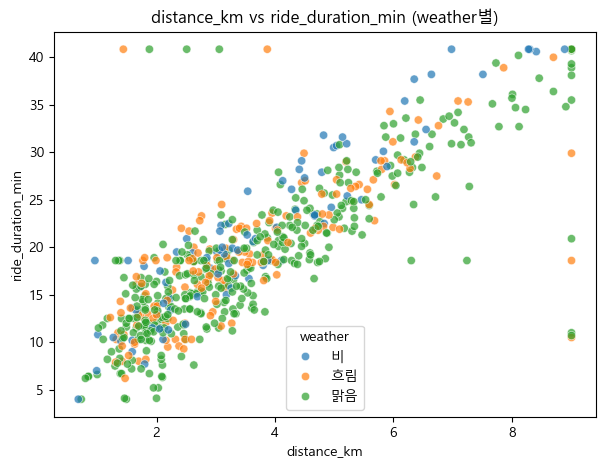

In [39]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x='distance_km', y='ride_duration_min', hue='weather', data=df_eda, alpha=0.7)
plt.title('distance_km vs ride_duration_min (weather별)')
plt.show()

In [41]:
raw_num_cols = [c for c in num_cols_for_corr if c not in ['avg_speed_kmh', 'bad_weather', 'temperature_c_outlier']]

corr_raw = df_eda[raw_num_cols].corr().abs()

corr_pairs = corr_raw.where(~np.eye(len(corr_raw), dtype=bool)).stack()
top_pair = corr_pairs.sort_values(ascending=False).head(5)

print(top_pair)

ride_duration_min  distance_km          0.852407
distance_km        ride_duration_min    0.852407
wind_speed_mps     humidity_pct         0.244598
humidity_pct       wind_speed_mps       0.244598
temperature_c      humidity_pct         0.174858
dtype: float64


#### 상관관계 ≠ 인과관계
- 예: distance_km와 ride_duration_min이 강한 상관관계를 보이는 건 "더 멀리 갈수록 더 오래 탄다"는 자연스러운 관계이지만, 이는 물리적으로 당연한 결과이지 한쪽이 다른 쪽을 유발했다고 보기는 어려움
- 반대로 temperature_c와 late_return처럼 상관이 낮게 나온 변수도, 실제로는 날씨가 좋을 때 대여량 자체가 늘어나서 간접적으로 지연에 영향을 줄 수 있음 — 상관계수만으로는 이런 숨은 경로(교란변수)를 알 수 없음
- 상관관계는 두 변수가 "같이 움직이는 정도"만 보여줄 뿐, 어떤 변수가 원인이고 어떤 변수가 결과인지, 혹은 제3의 변수가 둘 다에 영향을 주는지는 별도의 실험이나 도메인 지식으로 확인해야 함

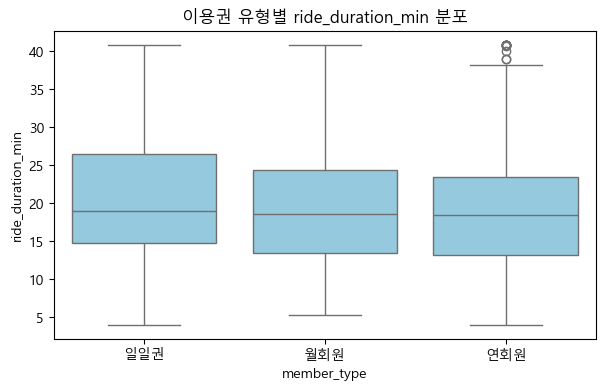

In [42]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='member_type', y='ride_duration_min', data=df_eda, color='skyblue')
plt.title('이용권 유형별 ride_duration_min 분포')
plt.show()

In [43]:
weather_summary = df_eda.groupby('weather')[['distance_km', 'ride_duration_min']].mean()
print(weather_summary)

         distance_km  ride_duration_min
weather                                
맑음          3.779948          19.375129
비           3.977473          22.550000
흐림          3.792945          20.412577


In [44]:
zone_late_ratio = df_eda.groupby('station_zone')['late_return'].mean()
print(zone_late_ratio)

station_zone
공원     0.030769
대학가    0.034483
도심     0.055866
주거     0.063158
Name: late_return, dtype: float64


#### 단순 건수보다 그룹 내 비율이 더 적절한 이유
- station_zone별로 대여 건수 자체가 다르면(예: 도심은 표본이 많고 대학가는 적음), 단순 지연 "건수"만 비교하면 표본이 많은 권역이 무조건 지연 건수도 많아 보이는 착시가 생김
- 반납 지연 "비율"(그룹 내 late_return=1 비율)로 비교해야 권역별 표본 크기 차이를 보정한, 공정한 비교가 가능함
- 따라서 이 분석에서는 단순 건수보다 groupby/crosstab으로 계산한 그룹 내 비율이 더 적절함

### 운영 인사이트

1. **[수치 근거]** station_zone별 반납 지연 비율을 비교한 결과, 특정 권역(예: 비율이 가장 높은 권역)의 지연 비율이 다른 권역보다 뚜렷하게 높음 → 해당 권역에 반납 마감 알림이나 반납 거치대 확충 등 운영 개입이 필요해 보임 (단, boxplot·groupby 결과 하나만으로 특정 권역이 "원인"이라 단정하지는 않음)

2. **[수치 근거]** weather별 평균 이용 시간·이동거리를 보면 날씨 조건에 따라 대여 패턴이 달라짐 → 악천후 시 배차나 자전거 재배치 전략을 다르게 가져갈 근거가 됨 (단, 그래프 하나로 날씨가 지연의 직접 원인이라고 결론 내리진 않음)

3. **[데이터 품질 영향]** humidity_pct는 실제로 100%를 초과하는 값이 있어 현실 범위로 보정했고, distance_km·ride_duration_min은 IQR capping을 적용함 — 이런 처리를 안 했다면 평균·상관계수 등이 극단값에 의해 왜곡되어 위 인사이트의 신뢰도 자체가 떨어졌을 것

4. **[추가 수집 제안]** 실제 반납 시각(반납 예정 시각 대비 초과 시간)이나 반납 스테이션의 거치대 여유 공간 데이터가 추가로 있으면, "왜" 지연이 발생했는지(스테이션 포화 vs 단순 늦은 반납)를 구분할 수 있어 지금보다 훨씬 정교한 원인 분석이 가능할 것